In [59]:
from ahrs.filters import Madgwick
from ahrs import Quaternion
import numpy as np

from matplotlib import pyplot as plt

In [60]:
from parse import Parser
import random

parser = Parser()
mc_x, mc_y = parser.read_mincopter_log('../../build-generic/mincopter_log.txt')
gz_x, gz_y = parser.read_gz_log('/tmp/gz_imu_logfile.txt')

In [61]:
print(gz_x.keys())


dict_keys(['ax', 'ay', 'az', 'gx', 'gy', 'gz', 'mx', 'my', 'mz'])


(2069, 3)
float64
(2070, 3)
float64
(2069, 3)
float64


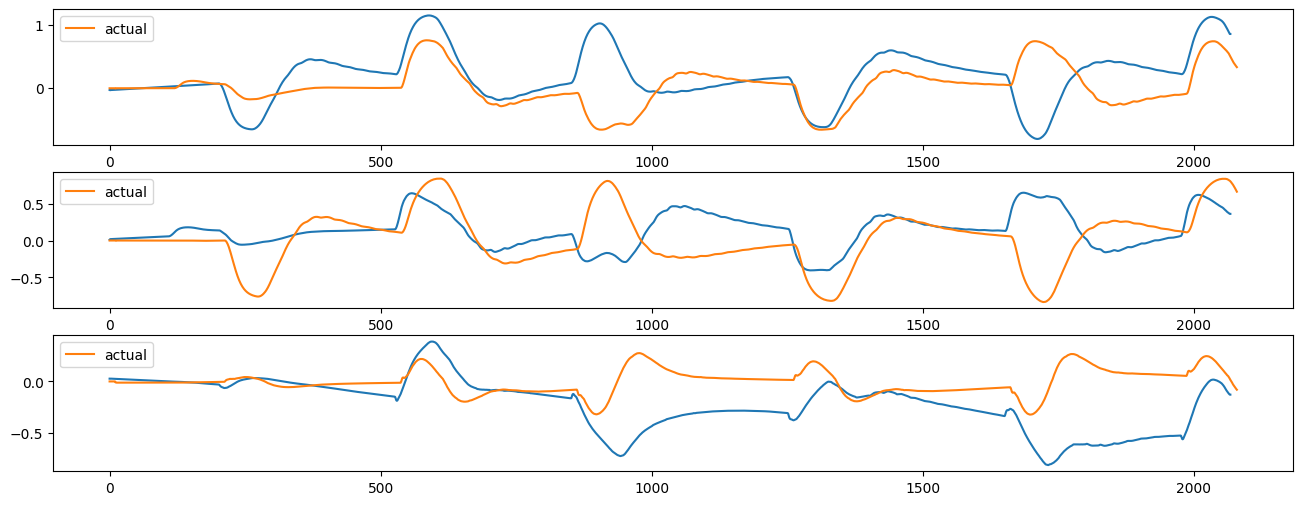

In [73]:
use_ned=False
gdata = np.array([
    gz_y['gx'][::10] if use_ned else gz_y['gy'][::10],
    gz_y['gy'][::10] if use_ned else gz_y['gx'][::10],
    gz_y['gz'][::10] if use_ned else [-1*e for e in gz_y['gz'][::10]]]).T
print(gdata.shape)
print(gdata.dtype)

adata = np.array([
    gz_y['ax'][::10] if use_ned else gz_y['ay'][::10],
    gz_y['ay'][::10] if use_ned else gz_y['ax'][::10],
    gz_y['az'][::10] if use_ned else [-1*e for e in gz_y['az'][::10]]]).T
print(adata.shape)
print(adata.dtype)

mdata = np.array([
    gz_y['mx'][::10] if use_ned else gz_y['my'][::10],
    gz_y['my'][::10] if use_ned else gz_y['mx'][::10],
    gz_y['mz'][::10] if use_ned else [-1*e for e in gz_y['mz'][::10]]]).T
print(mdata.shape)
print(mdata.dtype)

xlen = min(gdata.shape[0], adata.shape[0])

out = np.zeros((xlen, 4))

q0 = np.array([1,0,0,0], dtype=np.float64)
m = Madgwick() # gyr=gdata[:xlen,:], arr=adata[:xlen, :])
for i in range(0,xlen):
    out[i, :] = m.updateMARG(q0 if i==0 else out[i-1,:], gyr=gdata[i,:], acc=adata[i,:], mag=1e5*mdata[i,:])

fig, ax = plt.subplots(3,1, figsize=(16,6))
ax[0].plot([Quaternion(out[i][:]).to_angles()[0] for i in range(0,xlen)])
ax[0].plot(mc_y['roll'], label='actual')
ax[1].plot([Quaternion(out[i][:]).to_angles()[1] for i in range(0,xlen)])
ax[1].plot(mc_y['pitch'], label='actual')
ax[2].plot([Quaternion(out[i][:]).to_angles()[2] for i in range(0,xlen)])
ax[2].plot(mc_y['yaw'], label='actual')
[ax[i].legend() for i in range(0,3)];